## Install dependencies

Install the libraries required for loading Hugging Face models, applying bitsandbytes quantization, running benchmarks, and plotting results.

In [5]:
!pip install -q transformers accelerate bitsandbytes datasets pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 37.3 MB/s eta 0:00:00


In [6]:
# Check GPU runtime
!nvidia-smi

Sat Jun 27 19:46:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
## Import libraries and define model setup
import torch
import time
import gc
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

print("Device:", DEVICE)
print(torch.cuda.get_device_name(0))

Device: cuda
Tesla T4


In [8]:
## GPU memory cleanup helper
def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

## Load FP16, INT8, or INT4 model

This function loads the same Qwen model in three precision settings:
- FP16: standard half-precision GPU inference
- INT8: 8-bit quantized inference using bitsandbytes
- INT4: 4-bit quantized inference using bitsandbytes NF4

The goal is to compare whether lower precision reduces latency, memory, and improves throughput on Tesla T4.

In [9]:
def load_model(precision):
    clear_memory()

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if precision == "fp16":
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=True
        )

    elif precision == "int8":
        bnb_config = BitsAndBytesConfig(
            load_in_8bit=True
        )

        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True
        )

    elif precision == "int4":
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True
        )

        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True
        )

    else:
        raise ValueError("precision must be fp16, int8, or int4")

    model.eval()
    return model, tokenizer

In [10]:
## Generate prompts with controlled input length
def make_prompt(target_tokens):
    base_sentence = (
        "Machine learning inference optimization requires measuring latency, memory, "
        "throughput, model size, kernel efficiency, and hardware utilization. "
    )

    text = base_sentence
    while len(text.split()) < target_tokens:
        text += base_sentence

    return text

## Benchmark generation latency, throughput, and memory

This function measures the main inference metrics:
- Time to first token / TTFT: approximation of prefill latency
- Decode latency: average time per generated token
- Tokens/sec: throughput
- Peak GPU memory: memory footprint during generation
- Actual generated tokens: confirms fair comparison across precisions

Warmup runs are used to reduce first-run noise, and measured runs are averaged for more stable results.

In [11]:
@torch.no_grad()
def benchmark_generation(
    model,
    tokenizer,
    prompt,
    max_new_tokens=50,
    batch_size=1,
    warmup_runs=2,
    measured_runs=5
):
    prompts = [prompt] * batch_size

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(DEVICE)

    input_tokens = inputs["input_ids"].shape[1]

    # Warmup
    for _ in range(warmup_runs):
        _ = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            min_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
        torch.cuda.synchronize()

    ttft_list = []
    total_time_list = []
    decode_ms_per_token_list = []
    tokens_per_sec_list = []
    peak_memory_list = []
    generated_tokens_list = []

    for _ in range(measured_runs):
        torch.cuda.reset_peak_memory_stats()

        # Time to first token
        start = time.perf_counter()
        _ = model.generate(
            **inputs,
            max_new_tokens=1,
            min_new_tokens=1,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
        torch.cuda.synchronize()
        ttft = time.perf_counter() - start

        # Full generation
        start = time.perf_counter()
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            min_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
        torch.cuda.synchronize()
        total_time = time.perf_counter() - start

        actual_generated_tokens = outputs.shape[1] - input_tokens

        if actual_generated_tokens > 1:
            decode_ms_per_token = ((total_time - ttft) / (actual_generated_tokens - 1)) * 1000
        else:
            decode_ms_per_token = None

        tokens_per_sec = actual_generated_tokens * batch_size / total_time
        peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 3)

        ttft_list.append(ttft * 1000)
        total_time_list.append(total_time * 1000)
        decode_ms_per_token_list.append(decode_ms_per_token)
        tokens_per_sec_list.append(tokens_per_sec)
        peak_memory_list.append(peak_memory)
        generated_tokens_list.append(actual_generated_tokens)

    return {
        "input_tokens": input_tokens,
        "target_new_tokens": max_new_tokens,
        "actual_generated_tokens_mean": pd.Series(generated_tokens_list).mean(),
        "batch_size": batch_size,
        "ttft_ms_mean": pd.Series(ttft_list).mean(),
        "ttft_ms_std": pd.Series(ttft_list).std(),
        "decode_ms_per_token_mean": pd.Series(decode_ms_per_token_list).mean(),
        "decode_ms_per_token_std": pd.Series(decode_ms_per_token_list).std(),
        "tokens_per_sec_mean": pd.Series(tokens_per_sec_list).mean(),
        "tokens_per_sec_std": pd.Series(tokens_per_sec_list).std(),
        "peak_memory_gb_mean": pd.Series(peak_memory_list).mean(),
        "total_time_ms_mean": pd.Series(total_time_list).mean()
    }

## Experiment 1: Baseline precision comparison

This experiment compares FP16, INT8, and INT4 on the same prompt and same output length. It checks whether quantization improves latency, throughput, and memory in a simple fixed setting.

In [12]:
results = []

prompt = make_prompt(128)

for precision in ["fp16", "int8", "int4"]:
    print(f"\nLoading {precision} model...")
    model, tokenizer = load_model(precision)

    result = benchmark_generation(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        max_new_tokens=100,
        batch_size=1
    )

    result["precision"] = precision
    result["experiment"] = "precision_comparison"
    results.append(result)

    del model
    clear_memory()

df_precision = pd.DataFrame(results)
df_precision


Loading fp16 model...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")



Loading int4 model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,input_tokens,target_new_tokens,actual_generated_tokens_mean,batch_size,ttft_ms_mean,ttft_ms_std,decode_ms_per_token_mean,decode_ms_per_token_std,tokens_per_sec_mean,tokens_per_sec_std,peak_memory_gb_mean,total_time_ms_mean,precision,experiment
0,177,100,100.0,1,38.010743,0.949233,31.840814,0.438105,31.350158,0.427952,0.939283,3190.251303,fp16,precision_comparison
1,177,100,100.0,1,169.810556,1.259865,146.297566,0.933118,6.824633,0.042979,0.609604,14653.269586,int8,precision_comparison
2,177,100,100.0,1,102.051731,12.272301,69.870155,2.611069,14.262978,0.536425,0.457824,7019.197121,int4,precision_comparison


## Experiment 2: Input-length sweep

### Does quantization behave differently when the prompt gets longer?

This experiment varies input prompt length while keeping output length fixed. It mainly studies the prefill phase using time-to-first-token.

In [13]:
input_lengths = [64, 256, 1024, 2048]
results = []

for precision in ["fp16", "int8", "int4"]:
    print(f"\nLoading {precision} model...")
    model, tokenizer = load_model(precision)

    for input_len in input_lengths:
        print(f"Running {precision}, input length approx {input_len}")

        prompt = make_prompt(input_len)

        result = benchmark_generation(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=20,
            batch_size=1
        )

        result["precision"] = precision
        result["target_input_tokens"] = input_len
        result["experiment"] = "input_length_sweep"
        results.append(result)

    del model
    clear_memory()

df_input = pd.DataFrame(results)
df_input


Loading fp16 model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Running fp16, input length approx 64
Running fp16, input length approx 256
Running fp16, input length approx 1024
Running fp16, input length approx 2048

Loading int8 model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Running int8, input length approx 64


...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Running int4, input length approx 64


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Running int4, input length approx 256
Running int4, input length approx 1024
Running int4, input length approx 2048


,input_tokens,target_new_tokens,actual_generated_tokens_mean,batch_size,ttft_ms_mean,ttft_ms_std,decode_ms_per_token_mean,decode_ms_per_token_std,tokens_per_sec_mean,tokens_per_sec_std,peak_memory_gb_mean,total_time_ms_mean,precision,target_input_tokens,experiment
0,89,20,20.0,1,44.378470,4.368308,36.833339,0.236046,26.874190,0.064486,0.935820,744.211908,fp16,64,input_length_sweep
1,353,20,20.0,1,39.164274,1.056549,34.124772,1.455055,29.128562,1.186432,0.956988,687.534936,fp16,256,input_length_sweep
2,1409,20,20.0,1,265.880848,1.886274,34.077091,2.361593,21.937781,1.036209,1.217023,913.345568,fp16,1024,input_length_sweep
3,2817,20,20.0,1,963.003367,14.971954,32.921270,0.391654,12.591864,0.149551,1.985494,1588.507492,fp16,2048,input_length_sweep
4,89,20,20.0,1,172.869574,2.334916,152.304077,8.634923,6.536073,0.336756,0.603851,3066.647030,int8,64,input_length_sweep
5,353,20,20.0,1,191.253157,6.141881,145.706766,1.810759,6.758095,0.071514,0.623760,2959.681710,int8,256,input_length_sweep
6,1409,20,20.0,1,441.949754,3.452856,143.705092,1.810952,6.305108,0.070418,0.883591,3172.346505,int8,1024,input_length_sweep
7,2817,20,20.0,1,1123.491379,14.553731,143.261547,2.070089,5.201445,0.057683,1.651275,3845.460769,int8,2048,input_length_sweep
8,89,20,20.0,1,92.963367,1.532146,69.321773,0.575400,14.184401,0.117552,0.454611,1410.077056,int4,64,input_length_sweep
9,353,20,20.0,1,93.479630,2.223660,67.817262,0.631545,14.472599,0.127670,0.464252,1382.007612,int4,256,input_length_sweep


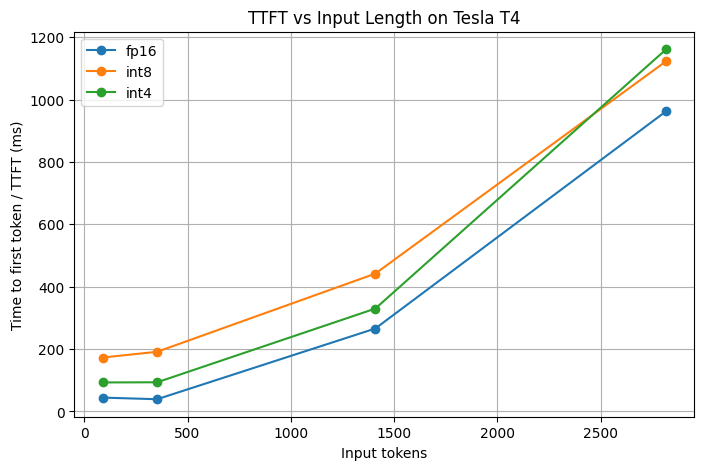

In [14]:
## Plot TTFT vs input length
plt.figure(figsize=(8, 5))

for precision in df_input["precision"].unique():
    subset = df_input[df_input["precision"] == precision]
    plt.plot(
        subset["input_tokens"],
        subset["ttft_ms_mean"],
        marker="o",
        label=precision
    )

plt.xlabel("Input tokens")
plt.ylabel("Time to first token / TTFT (ms)")
plt.title("TTFT vs Input Length on Tesla T4")
plt.legend()
plt.grid(True)
plt.show()

## Experiment 3: Output-length sweep

This experiment keeps the input prompt fixed and varies the number of generated output tokens. It mainly studies the decode phase, where the model generates one token at a time.

In [ ]:
#output length sweep
output_lengths = [20, 50, 100, 200]
results = []

prompt = make_prompt(128)

for precision in ["fp16", "int8", "int4"]:
    print(f"\nLoading {precision} model...")
    model, tokenizer = load_model(precision)

    for output_len in output_lengths:
        print(f"Running {precision}, output length {output_len}")

        result = benchmark_generation(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=output_len,
            batch_size=1
        )

        result["precision"] = precision
        result["target_output_tokens"] = output_len
        result["experiment"] = "output_length_sweep"
        results.append(result)

    del model
    clear_memory()

df_output = pd.DataFrame(results)
df_output


Loading fp16 model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Running fp16, output length 20
Running fp16, output length 50
Running fp16, output length 100
Running fp16, output length 200

Loading int8 model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Running int8, output length 20


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Running int8, output length 50


In [ ]:
## Plot decode latency vs output length
plt.figure(figsize=(8, 5))

for precision in df_output["precision"].unique():
    subset = df_output[df_output["precision"] == precision]
    plt.plot(
        subset["target_output_tokens"],
        subset["decode_ms_per_token_mean"],
        marker="o",
        label=precision
    )

plt.xlabel("Generated output tokens")
plt.ylabel("Decode latency (ms/token)")
plt.title("Decode Latency vs Output Length on Tesla T4")
plt.legend()
plt.grid(True)
plt.show()

## Experiment 4: Batch-size sweep

This experiment measures how throughput changes when multiple prompts are processed together. It checks whether quantized models become more efficient when batch size increases.

In [17]:
#batch size sweep
batch_sizes = [1, 2, 4, 8]
results = []

prompt = make_prompt(128)

for precision in ["fp16", "int8", "int4"]:
    print(f"\nLoading {precision} model...")
    model, tokenizer = load_model(precision)

    for batch_size in batch_sizes:
        print(f"Running {precision}, batch size {batch_size}")

        try:
            result = benchmark_generation(
                model=model,
                tokenizer=tokenizer,
                prompt=prompt,
                max_new_tokens=50,
                batch_size=batch_size
            )

            result["precision"] = precision
            result["target_batch_size"] = batch_size
            result["experiment"] = "batch_size_sweep"
            results.append(result)

        except torch.cuda.OutOfMemoryError:
            print(f"OOM for {precision}, batch size {batch_size}")
            clear_memory()

    del model
    clear_memory()

df_batch = pd.DataFrame(results)
df_batch


Loading fp16 model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Running fp16, batch size 1
Running fp16, batch size 2
Running fp16, batch size 4
Running fp16, batch size 8

Loading int8 model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Running int8, batch size 1


...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Running int4, batch size 1


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Running int4, batch size 2
Running int4, batch size 4
Running int4, batch size 8


,input_tokens,target_new_tokens,actual_generated_tokens_mean,batch_size,ttft_ms_mean,ttft_ms_std,decode_ms_per_token_mean,decode_ms_per_token_std,tokens_per_sec_mean,tokens_per_sec_std,peak_memory_gb_mean,total_time_ms_mean,precision,target_batch_size,experiment
0,177,50,50.0,1,38.097292,0.689234,31.113204,0.423745,32.001423,0.417734,0.939423,1562.644283,fp16,1,batch_size_sweep
1,177,50,50.0,2,38.485461,0.852202,32.024362,0.245832,62.204082,0.451218,0.949193,1607.679195,fp16,2,batch_size_sweep
2,177,50,50.0,4,49.351499,1.353009,32.762314,0.334352,120.876641,1.175063,0.968859,1654.704890,fp16,4,batch_size_sweep
3,177,50,50.0,8,115.152398,1.067697,33.559990,0.446964,227.355451,2.923611,1.006638,1759.591887,fp16,8,batch_size_sweep
4,177,50,50.0,1,173.165592,5.038294,147.119354,1.651739,6.773931,0.077734,0.609604,7382.013939,int8,1,batch_size_sweep
5,177,50,50.0,2,194.398204,3.399418,166.209081,1.952877,11.993682,0.140736,0.620670,8338.643167,int8,2,batch_size_sweep
6,177,50,50.0,4,236.486116,8.061190,165.778659,1.802779,23.926421,0.242196,0.643353,8359.640423,int8,4,batch_size_sweep
7,177,50,50.0,8,300.739775,2.992045,161.248322,1.541632,48.772254,0.433086,0.689118,8201.907532,int8,8,batch_size_sweep
8,177,50,50.0,1,96.215093,2.933615,69.176483,1.544300,14.349081,0.309537,0.457824,3485.862752,int4,1,batch_size_sweep
9,177,50,50.0,2,98.719013,2.572555,91.623752,1.541737,21.799641,0.367575,0.464277,4588.282861,int4,2,batch_size_sweep


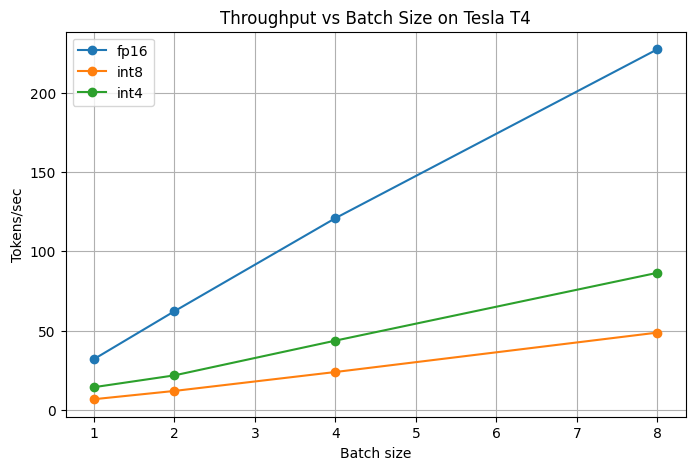

In [18]:
### Plot throughput vs batch size
plt.figure(figsize=(8, 5))

for precision in df_batch["precision"].unique():
    subset = df_batch[df_batch["precision"] == precision]
    plt.plot(
        subset["target_batch_size"],
        subset["tokens_per_sec_mean"],
        marker="o",
        label=precision
    )

plt.xlabel("Batch size")
plt.ylabel("Tokens/sec")
plt.title("Throughput vs Batch Size on Tesla T4")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
#Profiler
from torch.profiler import profile, ProfilerActivity, record_function
import torch
import gc

def run_profiler(model, tokenizer, prompt, precision_name, max_new_tokens=50):
    """
    Profiles one generation run.
    Use this after loading a model with load_model("fp16"), load_model("int4"), etc.
    """

    model.eval()

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to("cuda")

    # Warmup runs: ignore these so first-run overhead does not pollute profiler
    for _ in range(2):
        _ = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            min_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
        torch.cuda.synchronize()

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=True,
        profile_memory=True,
        with_stack=False
    ) as prof:
        with record_function(f"{precision_name}_generation"):
            _ = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                min_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
            torch.cuda.synchronize()

    print(f"\n===== PROFILER RESULTS: {precision_name.upper()} =====")
    print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / (1024**3):.3f} GB")

    print("\n--- Top ops by CUDA time ---")
    print(
        prof.key_averages().table(
            sort_by="cuda_time_total",
            row_limit=25
        )
    )

    print("\n--- Top ops by CPU time ---")
    print(
        prof.key_averages().table(
            sort_by="cpu_time_total",
            row_limit=25
        )
    )

    return prof

In [20]:
#For FP16 model
prompt = make_prompt(128)

print("Loading FP16 model...")
model_fp16, tokenizer_fp16 = load_model("fp16")

prof_fp16 = run_profiler(
    model=model_fp16,
    tokenizer=tokenizer_fp16,
    prompt=prompt,
    precision_name="fp16",
    max_new_tokens=50
)

del model_fp16
gc.collect()
torch.cuda.empty_cache()

Loading FP16 model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(



===== PROFILER RESULTS: FP16 =====
Peak GPU memory: 0.939 GB

--- Top ops by CUDA time ---
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        fp16_generation         0.00%       0.000us         0.00%       0.000us       0.000us        2.872s     

In [21]:
#For INT4
print("Loading INT4 model...")
model_int4, tokenizer_int4 = load_model("int4")

prof_int4 = run_profiler(
    model=model_int4,
    tokenizer=tokenizer_int4,
    prompt=prompt,
    precision_name="int4",
    max_new_tokens=50
)

del model_int4
gc.collect()
torch.cuda.empty_cache()

Loading INT4 model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



===== PROFILER RESULTS: INT4 =====
Peak GPU memory: 0.458 GB

--- Top ops by CUDA time ---
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        int4_generation         0.00%       0.000us         0.00%       0.000us       0.000us        5.815s     

In [22]:
import torch, time, gc
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

DEVICE = "cuda"
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

In [23]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_fp16 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map="cuda"
)
model_fp16.eval()
print("FP16 loaded")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

FP16 loaded


In [24]:
model_int8 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=BitsAndBytesConfig(load_in_8bit=True), device_map="cuda"
)
model_int8.eval()
print("INT8 loaded")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

INT8 loaded


In [25]:
model_int4 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True
    ), device_map="cuda"
)
model_int4.eval()
print("INT4 loaded")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

INT4 loaded


In [26]:
!pip install fvcore -q

from fvcore.nn import FlopCountAnalysis

def measure_flops(model, tokenizer, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        flops = FlopCountAnalysis(model, inputs["input_ids"])
        flops.unsupported_ops_warnings(False)
        flops.uncalled_modules_warnings(False)
        total_flops = flops.total()

    return total_flops / 1e9  # convert to GFLOPs

In [27]:
#Installing pynvml for energy measurement
!pip install pynvml -q


In [28]:

# Energy measurement setup

import pynvml
import threading
import time
import numpy as np

pynvml.nvmlInit()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)

def sample_power(stop_event, readings):
    """Runs in a background thread, polls GPU power every 50ms."""
    while not stop_event.is_set():
        mw = pynvml.nvmlDeviceGetPowerUsage(handle)  # returns milliwatts
        readings.append(mw / 1000.0)  # convert to watts
        time.sleep(0.05)

def measure_energy(model, inputs, generate_kwargs):
    """
    Runs one generation pass, samples power throughout,
    returns (output_tokens, elapsed_seconds, joules, watts_avg).
    """
    readings = []
    stop_event = threading.Event()
    t = threading.Thread(target=sample_power, args=(stop_event, readings))

    torch.cuda.synchronize()
    t.start()
    t0 = time.perf_counter()

    with torch.no_grad():
        out = model.generate(**inputs, **generate_kwargs)

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    stop_event.set()
    t.join()

    watts_avg = np.mean(readings) if readings else 0
    joules = watts_avg * elapsed
    n_new_tokens = out.shape[1] - inputs["input_ids"].shape[1]

    return n_new_tokens, elapsed, joules, watts_avg




In [29]:
# Running energy benchmark across all three precisions
PROMPT = "Explain the tradeoffs between model quantization and inference latency in large language models."
inputs = tokenizer(PROMPT, return_tensors="pt").to("cuda")
GEN_KWARGS = {"max_new_tokens": 100, "do_sample": False}

energy_results = []

for name, model in [("FP16", model_fp16), ("INT8", model_int8), ("INT4", model_int4)]:
    # warmup
    with torch.no_grad():
        model.generate(**inputs, max_new_tokens=20, do_sample=False)
    torch.cuda.synchronize()

    # actual measurement
    n_tokens, elapsed, joules, watts = measure_energy(model, inputs, GEN_KWARGS)

    energy_results.append({
        "Precision": name,
        "Tokens Generated": n_tokens,
        "Time (s)": round(elapsed, 3),
        "Avg Power (W)": round(watts, 2),
        "Total Energy (J)": round(joules, 3),
        "J / Token": round(joules / n_tokens, 4) if n_tokens > 0 else None,
    })
    print(f"{name}: {n_tokens} tokens | {elapsed:.2f}s | {watts:.1f}W avg | {joules:.2f}J | {joules/n_tokens:.4f} J/token")

energy_df = pd.DataFrame(energy_results)
print("\n", energy_df.to_string(index=False))




FP16: 100 tokens | 3.98s | 41.6W avg | 165.37J | 1.6537 J/token


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


INT8: 100 tokens | 16.91s | 36.4W avg | 615.41J | 6.1541 J/token
INT4: 100 tokens | 8.12s | 37.5W avg | 304.46J | 3.0446 J/token

 Precision  Tokens Generated  Time (s)  Avg Power (W)  Total Energy (J)  J / Token
     FP16               100     3.977          41.58           165.375     1.6537
     INT8               100    16.912          36.39           615.408     6.1541
     INT4               100     8.119          37.50           304.456     3.0446


In [30]:
# ============================================================
# CELL 4 — torch.profiler (run once per model — do FP16 first)
# ============================================================
# NOTE: Run this cell separately for each model by changing `model_to_profile`
# and `label` below. Running all three at once is slow and the trace file
# gets huge. Each run produces a .json you can open in chrome://tracing

from torch.profiler import profile, record_function, ProfilerActivity

model_to_profile = model_fp16   # <-- change to model_int8 or model_int4
label = "fp16"                  # <-- change to match

prof_inputs = tokenizer("Explain quantization tradeoffs.", return_tensors="pt").to("cuda")

# warmup
with torch.no_grad():
    model_to_profile.generate(**prof_inputs, max_new_tokens=10, do_sample=False)
torch.cuda.synchronize()

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    with_stack=False,
    schedule=torch.profiler.schedule(wait=0, warmup=0, active=1),
) as prof:
    with record_function(f"generate_{label}"):
        with torch.no_grad():
            model_to_profile.generate(**prof_inputs, max_new_tokens=30, do_sample=False)
    prof.step()

# Print top 20 ops by CUDA time
print(f"\n=== Top CUDA ops for {label.upper()} ===")
print(prof.key_averages().table(
    sort_by="cuda_time_total",
    row_limit=20
))

# Save trace for chrome://tracing (optional but useful)
prof.export_chrome_trace(f"/content/trace_{label}.json")
print(f"\nTrace saved → trace_{label}.json")



/tmp/ipykernel_5554/3176345325.py:24: UserWarning: Profiler won't be using warmup, this can skew profiler results
  schedule=torch.profiler.schedule(wait=0, warmup=0, active=1),



=== Top CUDA ops for FP16 ===
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
              ProfilerStep*         7.31%     113.799us         7.31%     113.799us     113.799us             1  
      cudaDeviceSynchronize         1.99%      31.044us         1.99%      31.044us      31.044us             1  
    Activity Buffer Request        90.69%       1.412ms        90.69%       1.412ms       1.412ms             1  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 1.556ms


Trace saved → trace_fp16.json


In [31]:
from torch.profiler import profile, record_function, ProfilerActivity

# ============================================================
# CELL 4a — FP16 Profiler
# ============================================================
model_to_profile = model_fp16
label = "fp16"

prof_inputs = tokenizer("Explain quantization tradeoffs.", return_tensors="pt").to("cuda")

with torch.no_grad():
    model_to_profile.generate(**prof_inputs, max_new_tokens=10, do_sample=False)
torch.cuda.synchronize()

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    with_stack=False,
    schedule=torch.profiler.schedule(wait=0, warmup=0, active=1),
) as prof:
    with record_function(f"generate_{label}"):
        with torch.no_grad():
            model_to_profile.generate(**prof_inputs, max_new_tokens=30, do_sample=False)
    prof.step()

print(f"\n=== Top CUDA ops for {label.upper()} ===")
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=20))
prof.export_chrome_trace(f"/content/trace_{label}.json")
print(f"Trace saved → trace_{label}.json")


# ============================================================
# CELL 4b — INT8 Profiler
# ============================================================
model_to_profile = model_int8
label = "int8"

prof_inputs = tokenizer("Explain quantization tradeoffs.", return_tensors="pt").to("cuda")

with torch.no_grad():
    model_to_profile.generate(**prof_inputs, max_new_tokens=10, do_sample=False)
torch.cuda.synchronize()

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    with_stack=False,
    schedule=torch.profiler.schedule(wait=0, warmup=0, active=1),
) as prof:
    with record_function(f"generate_{label}"):
        with torch.no_grad():
            model_to_profile.generate(**prof_inputs, max_new_tokens=30, do_sample=False)
    prof.step()

print(f"\n=== Top CUDA ops for {label.upper()} ===")
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=20))
prof.export_chrome_trace(f"/content/trace_{label}.json")
print(f"Trace saved → trace_{label}.json")


# ============================================================
# CELL 4c — INT4 Profiler
# ============================================================
model_to_profile = model_int4
label = "int4"

prof_inputs = tokenizer("Explain quantization tradeoffs.", return_tensors="pt").to("cuda")

with torch.no_grad():
    model_to_profile.generate(**prof_inputs, max_new_tokens=10, do_sample=False)
torch.cuda.synchronize()

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    with_stack=False,
    schedule=torch.profiler.schedule(wait=0, warmup=0, active=1),
) as prof:
    with record_function(f"generate_{label}"):
        with torch.no_grad():
            model_to_profile.generate(**prof_inputs, max_new_tokens=30, do_sample=False)
    prof.step()

print(f"\n=== Top CUDA ops for {label.upper()} ===")
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=20))
prof.export_chrome_trace(f"/content/trace_{label}.json")
print(f"Trace saved → trace_{label}.json")

/tmp/ipykernel_5554/2671857356.py:19: UserWarning: Profiler won't be using warmup, this can skew profiler results
  schedule=torch.profiler.schedule(wait=0, warmup=0, active=1),



=== Top CUDA ops for FP16 ===
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
              ProfilerStep*         5.16%      83.104us         5.16%      83.104us      83.104us             1  
      cudaDeviceSynchronize         1.42%      22.917us         1.42%      22.917us      22.917us             1  
    Activity Buffer Request        93.42%       1.506ms        93.42%       1.506ms       1.506ms             1  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 1.612ms

Trace saved → trace_fp16.json


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/tmp/ipykernel_5554/2671857356.py:48: UserWarning: Profiler won't be using warmup, this can skew profiler results
  schedule=torch.profiler.schedule(wait=0, warmup=0, active=1),



=== Top CUDA ops for INT8 ===
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
              ProfilerStep*         4.79%      82.058us         4.79%      82.058us      82.058us             1  
      cudaDeviceSynchronize         1.52%      26.120us         1.52%      26.120us      26.120us             1  
    Activity Buffer Request        93.69%       1.605ms        93.69%       1.605ms       1.605ms             1  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 1.714ms

Trace saved → trace_int8.json


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/tmp/ipykernel_5554/2671857356.py:77: UserWarning: Profiler won't be using warmup, this can skew profiler results
  schedule=torch.profiler.schedule(wait=0, warmup=0, active=1),



=== Top CUDA ops for INT4 ===
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
              ProfilerStep*         5.03%      84.954us         5.03%      84.954us      84.954us             1  
      cudaDeviceSynchronize         1.53%      25.782us         1.53%      25.782us      25.782us             1  
    Activity Buffer Request        93.45%       1.579ms        93.45%       1.579ms       1.579ms             1  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 1.690ms

Trace saved → trace_int4.json


In [32]:
# ============================================================
# FIXED PROFILER — runs all 3 models, captures actual kernels
# ============================================================
from torch.profiler import profile, record_function, ProfilerActivity

prof_inputs = tokenizer("Explain quantization tradeoffs.", return_tensors="pt").to("cuda")

for name, model in [("FP16", model_fp16), ("INT8", model_int8), ("INT4", model_int4)]:
    label = name.lower()

    # warmup — run outside the profiler
    with torch.no_grad():
        model.generate(**prof_inputs, max_new_tokens=10, do_sample=False)
    torch.cuda.synchronize()

    # profile — NO schedule, just wrap the call directly
    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=True,
        with_stack=False,
    ) as prof:
        with record_function(f"generate_{label}"):
            with torch.no_grad():
                model.generate(**prof_inputs, max_new_tokens=30, do_sample=False)

    print(f"\n=== Top CUDA ops for {name} ===")
    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))
    prof.export_chrome_trace(f"/content/trace_{label}.json")
    print(f"Trace saved → trace_{label}.json\n")


=== Top CUDA ops for FP16 ===
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          generate_fp16         0.00%       0.000us         0.00%       0.000us       0.000us        2.106s       542.54%        2.106s        2.106s             1  
                                          generate_fp16        23.84%     503.637ms       100.00%        2.113s        2.113s       0.000us         0.00%     388.342ms     388.


# CONCLUSION

## Profiler Analysis: Why FP16 Wins on T4

### Total CUDA Time
| Precision | CUDA Time | Relative to FP16 |
|-----------|-----------|------------------|
| FP16      | 388ms     | 1x (baseline)    |
| INT4      | 572ms     | 1.47x slower     |
| INT8      | 894ms     | 2.3x slower      |

### Root Cause: Kernel Overhead

**FP16** executes one kernel per matmul: `aten::mm` (48.6% of CUDA time).
Native Tensor Core path. No overhead.

**INT8** executes a 4-step pipeline per matmul:
1. `int8_vectorwise_quant` — quantize activations (226ms)
2. `int8_scaled_mm` — compute in INT8 (210ms)  
3. `int8_mm_dequant` — dequantize result (88ms)
4. `aten::copy_` — cast bfloat16→float16 (150ms)

**INT4** — kernel name says it all: `kgemm_4bit_inference_naive`.
The word "naive" indicates bitsandbytes falls back to an
unoptimized path because T4 has no native INT4 compute hardware.
27.8% of CUDA time is just dtype casting (`aten::copy_`).

### Key Insight
The T4 (Turing, 2018) Tensor Cores are optimized for FP16.
Quantization only speeds up inference when the GPU has *native*
low-bit compute paths (Ampere A100 for INT8, Ada for FP4).
On T4, bitsandbytes adds quantize/dequantize overhead on every
matmul that outweighs any memory bandwidth savings.

Memory savings are real (INT8: 35% less, INT4: 51% less).
Latency savings are not — at least not on Turing-gen hardware.
"""